In [1]:
# Imports and Configuration
import struct
import numpy as np
import pyshark
import pandas as pd
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, Optional
import nest_asyncio
from collections import defaultdict, deque
import struct
from typing import List, Tuple, Optional

nest_asyncio.apply()

# Configure plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Exp1: window size and accuracy


=== Window Size 4 ===
Training Accuracy: 0.9727
Test Accuracy: 0.9723

Classification Report:
              precision    recall  f1-score   support

           0     0.9669    0.9947    0.9806    214736
           1     0.9865    0.9195    0.9518     90879

    accuracy                         0.9723    305615
   macro avg     0.9767    0.9571    0.9662    305615
weighted avg     0.9727    0.9723    0.9720    305615


Feature Importance:
             feature  importance
6   modbus_req_count    0.338002
2      pkt_size_mean    0.170717
3            iat_min    0.146719
7  modbus_resp_count    0.115367
5           iat_mean    0.110129
1       pkt_size_max    0.090691
4            iat_max    0.028299
0       pkt_size_min    0.000075

Saved model to random_forest_model_ws4.pkl
Saved feature list to feature_list_ws4.txt

=== Window Size 8 ===
Training Accuracy: 0.9801
Test Accuracy: 0.9796

Classification Report:
              precision    recall  f1-score   support

           0     0.9727

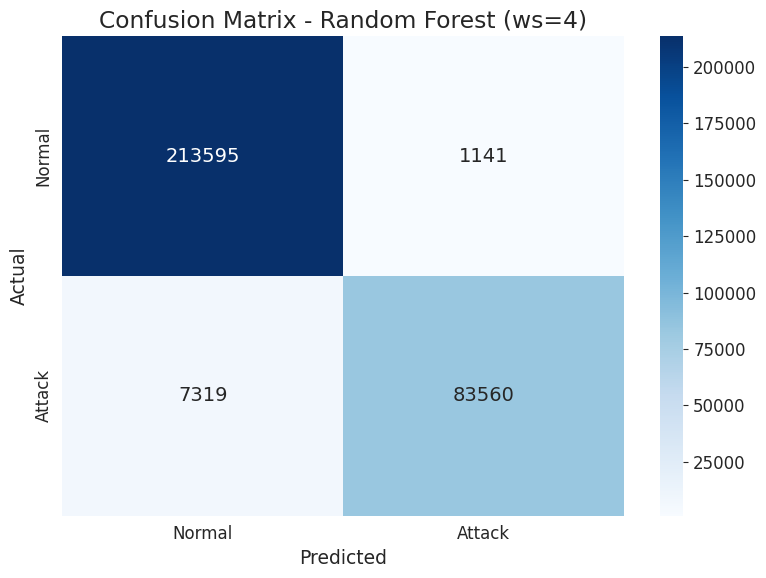

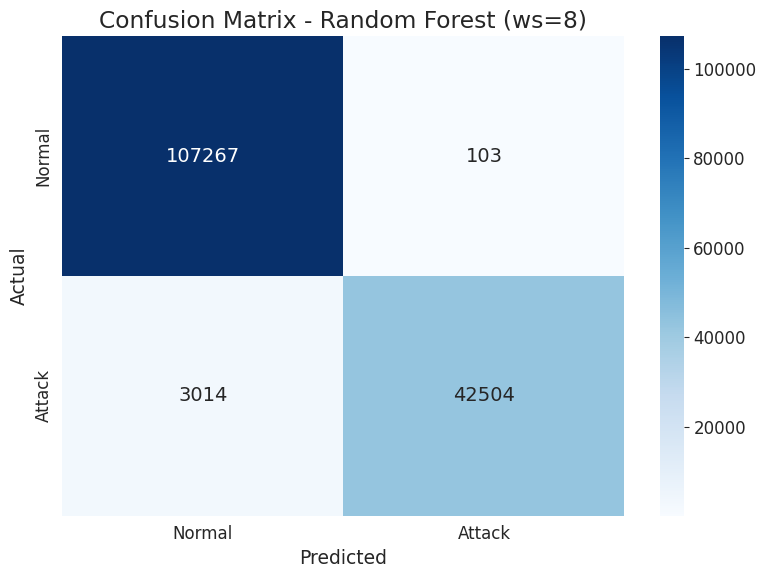

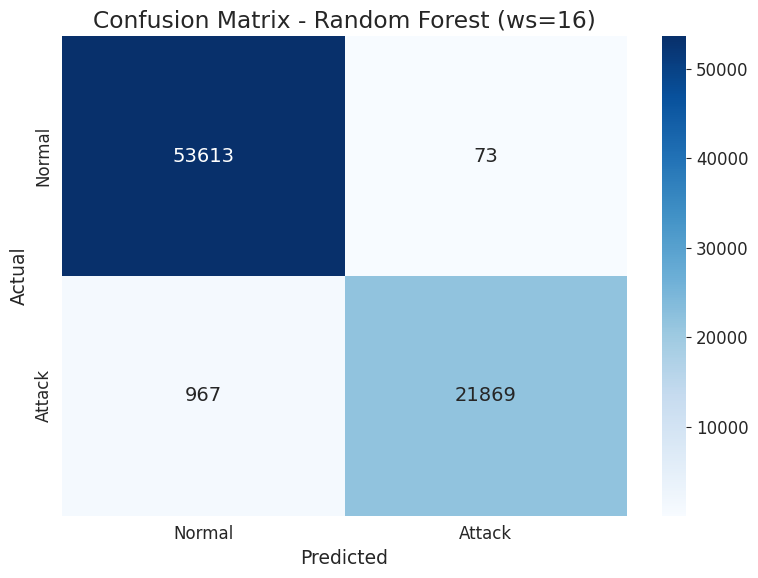

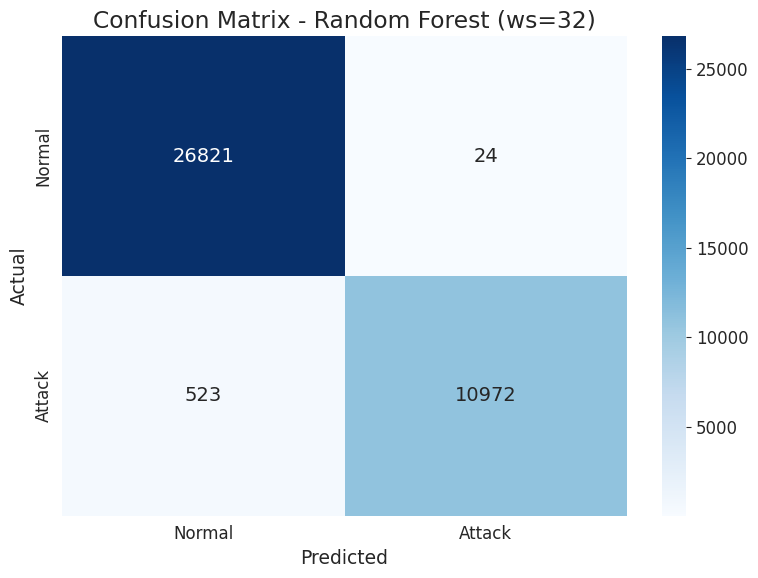

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

def plot_confusion_matrix(y_true, y_pred, ws):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(f'Confusion Matrix - Random Forest (ws={ws})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    # plt.show()

def train_rf_model_from_csv(normal_csv, attack_csv, ws):
    """Train Random Forest using CSV files"""

    # Load CSV files
    df_normal = pd.read_csv(normal_csv)
    df_attack = pd.read_csv(attack_csv)

    # Add labels
    df_normal = df_normal.copy()
    df_attack = df_attack.copy()
    df_normal["label"] = 0
    df_attack["label"] = 1

    # Combine datasets
    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # Select features
    feature_columns = [
        "pkt_size_min", "pkt_size_max", "pkt_size_mean",
        "iat_min", "iat_max", "iat_mean", "modbus_req_count", "modbus_resp_count"
    ]

    X = df[feature_columns]
    y = df["label"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=5,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Metrics
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n=== Window Size {ws} ===")
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy: {test_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion matrix
    plot_confusion_matrix(y_test, y_pred, ws)

    # Feature importance
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": rf.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    # Save feature list
    feature_list_file = f"feature_list_ws{ws}.txt"
    with open(feature_list_file, "w") as f:
        for feat in feature_importance_df["feature"]:
            f.write(feat + "\n")

    # Save model
    model_file = f"random_forest_model_ws{ws}.pkl"
    joblib.dump(rf, model_file)

    print(f"\nSaved model to {model_file}")
    print(f"Saved feature list to {feature_list_file}")

    return {
        "ws": ws,
        "train_acc": train_score,
        "test_acc": test_score,
        "feature_importance_df": feature_importance_df,
        "model_file": model_file,
        "feature_list_file": feature_list_file
    }

if __name__ == "__main__":
    window_sizes = [4, 8, 16, 32]
    results = []

    for ws in window_sizes:
        normal_csv = f"normal_ws{ws}.csv"
        attack_csv = f"attack_ws{ws}.csv"

        result = train_rf_model_from_csv(normal_csv, attack_csv, ws)
        results.append({
            "window_size": result["ws"],
            "train_accuracy": result["train_acc"],
            "test_accuracy": result["test_acc"],
            "model_file": result["model_file"],
            "feature_list_file": result["feature_list_file"]
        })

    results_df = pd.DataFrame(results)
    print("\nSummary:")
    print(results_df)

    results_df.to_csv("rf_results_summary.csv", index=False)
    print("\nSaved summary to rf_results_summary.csv")

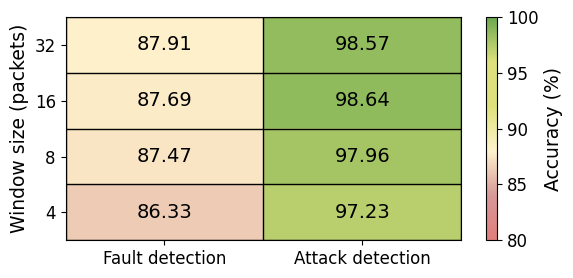

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data
ws = [4, 8, 16, 32][::-1]
features = ['Fault detection', 'Attack detection']

accuracy = np.array([
    [87.9105, 98.5733],
    [87.6871, 98.6409],
    [87.4732, 97.9613],
    [86.3281, 97.2318]
])

# hex_colors = ["#fff2cc", "#fff2cc", "#6aa84f", "#6aa84f"]
# cmap = LinearSegmentedColormap.from_list("custom_green", hex_colors)
# ---- Custom hex colormap ----
hex_colors = ["#E17E7B", "#D69997", "#fff2cc", "#dee17b","#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_blue", hex_colors)
# cmap = LinearSegmentedColormap.from_list(
#     "ylgn_custom",
#     ["#fff7cc", "#c2e699", "#78c679", "#238443"]
# )

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 13.5,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(6, 3))

im = ax.imshow(
    accuracy,
    aspect='auto',
    cmap=cmap,
    vmin=80,
    vmax=100,
    interpolation='nearest'
)

# Cell borders
ax.set_xticks(np.arange(-0.5, len(features), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ws), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Labels and ticks
ax.set_ylabel('Window size (packets)')
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.set_yticks(np.arange(len(ws)))
ax.set_yticklabels(ws)

# Colorbar
cbar = fig.colorbar(im, ax=ax, ticks=[80,85,90,95,100])
cbar.set_label('Accuracy (%)', fontsize=13.5)

# Annotate cells
for i in range(len(ws)):
    for j in range(len(features)):
        ax.text(j, i, f"{accuracy[i, j]:.2f}",
                ha="center", va="center", color="black")

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.savefig('exp1_ws_acc/ws_accuracy.pdf', dpi=300)
plt.show()

# Exp 2: accuracy at different tree sizes and window sizesfor RF wih 8 features

In [14]:
import os
import re
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

OUT_DIR = "exp2_tree_size/plots"
os.makedirs(OUT_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    "pkt_size_min", "pkt_size_max", "pkt_size_mean",
    "iat_min", "iat_max", "iat_mean",
    "modbus_req_count", "modbus_resp_count"
]

WINDOW_SIZES = [4, 8, 16, 32]
N_ESTIMATORS_LIST = [1, 5, 10, 25, 50]
MAX_DEPTH_LIST = [2, 4, 8, 16,32]

def plot_confusion_matrix(y_true, y_pred, ws, n_estimators, max_depth):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(f'Confusion Matrix - ws={ws}, trees={n_estimators}, depth={max_depth}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"cm_ws{ws}_trees{n_estimators}_depth{max_depth}.png")
    plt.savefig(out_path, dpi=200)
    # plt.show()
    plt.close()

def compute_tree_stats(rf):
    node_counts = [est.tree_.node_count for est in rf.estimators_]
    leaf_counts = [est.tree_.n_leaves for est in rf.estimators_]
    return {
        "avg_nodes_per_tree": float(np.mean(node_counts)),
        "total_nodes": int(np.sum(node_counts)),
        "avg_leaves_per_tree": float(np.mean(leaf_counts)),
        "total_leaves": int(np.sum(leaf_counts)),
    }

def train_rf_model_from_csv(normal_csv, attack_csv, ws, n_estimators, max_depth):
    """Train Random Forest using CSV files and return one result row."""

    df_normal = pd.read_csv(normal_csv).copy()
    df_attack = pd.read_csv(attack_csv).copy()

    df_normal["label"] = 0
    df_attack["label"] = 1

    df = pd.concat([df_normal, df_attack], ignore_index=True)

    X = df[FEATURE_COLUMNS]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    train_acc = rf.score(X_train, y_train)
    test_acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    try:
        y_prob = rf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    except Exception:
        roc_auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tree_stats = compute_tree_stats(rf)

    # print(f"\n=== ws={ws}, trees={n_estimators}, depth={max_depth} ===")
    # print(f"Training Accuracy: {train_acc:.4f}")
    # print(f"Test Accuracy: {test_acc:.4f}")
    # print(f"Precision: {prec:.4f}")
    # print(f"Recall: {rec:.4f}")
    # print(f"F1-score: {f1:.4f}")
    # if not np.isnan(roc_auc):
    #     print(f"ROC-AUC: {roc_auc:.4f}")
    # print("\nClassification Report:")
    # print(classification_report(y_test, y_pred, digits=4))

    plot_confusion_matrix(y_test, y_pred, ws, n_estimators, max_depth)

    feature_importance_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": rf.feature_importances_
    }).sort_values(by="importance", ascending=False)

    # print("\nFeature Importance:")
    # print(feature_importance_df)

    model_file = f"random_forest_ws{ws}_trees{n_estimators}_depth{max_depth}.pkl"
    feature_list_file = f"feature_list_ws{ws}_trees{n_estimators}_depth{max_depth}.txt"

    with open(feature_list_file, "w") as f:
        for feat in feature_importance_df["feature"]:
            f.write(feat + "\n")

    joblib.dump(rf, model_file)

    print(f"\nSaved model to {model_file}")
    print(f"Saved feature list to {feature_list_file}")

    return {
        "dataset": f"ws{ws}",
        "window_size": ws,
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "train_accuracy": train_acc,
        "accuracy": test_acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "avg_nodes_per_tree": tree_stats["avg_nodes_per_tree"],
        "total_nodes": tree_stats["total_nodes"],
        "avg_leaves_per_tree": tree_stats["avg_leaves_per_tree"],
        "total_leaves": tree_stats["total_leaves"],
        "model_file": model_file,
        "feature_list_file": feature_list_file
    }

def summarize_from_df(results_df):
    results_df = results_df.copy()

    results_df["window_size"] = pd.to_numeric(results_df["window_size"], errors="coerce")
    results_df["n_estimators"] = pd.to_numeric(results_df["n_estimators"], errors="coerce")
    results_df["max_depth"] = pd.to_numeric(results_df["max_depth"], errors="coerce")
    results_df["accuracy"] = pd.to_numeric(results_df["accuracy"], errors="coerce")
    results_df["roc_auc"] = pd.to_numeric(results_df["roc_auc"], errors="coerce")

    summary = (
        results_df.groupby("dataset")["accuracy"]
        .agg(["mean", "std", "count"])
        .rename(columns={
            "mean": "avg_accuracy",
            "std": "std_accuracy",
            "count": "n_configs"
        })
        .reset_index()
    )

    summary["dataset_num"] = summary["dataset"].str.extract(r"(\d+)").astype(int)
    summary = summary.sort_values("dataset_num").reset_index(drop=True)

    print("\nAverage accuracy per window size:")
    print(summary[["dataset", "avg_accuracy", "std_accuracy", "n_configs"]].to_string(index=False, float_format="%.6f"))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        summary["dataset"],
        summary["avg_accuracy"],
        yerr=summary["std_accuracy"].fillna(0),
        capsize=5,
        alpha=0.85
    )
    ax.set_ylabel("Average accuracy")
    ax.set_ylim(0, 1.0)
    ax.set_title("Average accuracy per window size")
    for i, v in enumerate(summary["avg_accuracy"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout()

    barpath = os.path.join(OUT_DIR, "avg_accuracy_per_window_size.png")
    plt.savefig(barpath, dpi=200)
    print(f"Saved bar plot to {barpath}")
    plt.close(fig)

    return summary

def plot_heatmaps(results_df):
    if "roc_auc" not in results_df.columns:
        print("No 'roc_auc' column found — skipping heatmaps.")
        return

    datasets = sorted(
        results_df["dataset"].unique(),
        key=lambda s: int("".join(filter(str.isdigit, s)) or 0)
    )

    for ds in datasets:
        df = results_df[results_df["dataset"] == ds].copy()

        pivot = df.pivot_table(
            index="n_estimators",
            columns="max_depth",
            values="roc_auc",
            aggfunc="mean"
        )

        if pivot.empty:
            print(f"Empty pivot for {ds}, skipping.")
            continue

        plt.figure(figsize=(8, 5))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            linewidths=.5,
            cbar_kws={"label": "ROC-AUC"},
            cmap="viridis"
        )
        plt.title(f"ROC-AUC heatmap — {ds} (rows=n_estimators, cols=max_depth)")
        plt.ylabel("n_estimators")
        plt.xlabel("max_depth")
        plt.tight_layout()

        heatpath = os.path.join(OUT_DIR, f"roc_auc_heatmap_{ds}.png")
        plt.savefig(heatpath, dpi=200)
        print(f"Saved heatmap for {ds} to {heatpath}")
        plt.close()

def plot_grouped_bars(results_df):
    datasets_sorted = sorted(
        results_df["dataset"].unique(),
        key=lambda s: int("".join(filter(str.isdigit, s)) or 0)
    )
    global_depths = sorted(results_df["max_depth"].dropna().unique())
    global_estimators = sorted(results_df["n_estimators"].dropna().unique())

    def _grouped_bar_for_metric(metric, ylabel, filename_suffix, log_scale=False, value_fmt="{:.3f}"):
        for ds in datasets_sorted:
            df = results_df[results_df["dataset"] == ds].copy()
            if df.empty:
                continue

            pivot = df.pivot_table(
                index="n_estimators",
                columns="max_depth",
                values=metric,
                aggfunc="mean"
            ).reindex(index=global_estimators, columns=global_depths)

            n_groups = len(pivot.index)
            n_depths = len(pivot.columns)
            bar_width = 0.8 / max(1, n_depths)
            x = np.arange(n_groups)

            fig, ax = plt.subplots(figsize=(10, 5))
            for i, depth in enumerate(pivot.columns):
                vals = pivot[depth].values
                ax.bar(x + i * bar_width, vals, width=bar_width, label=f"depth={int(depth)}")

            ax.set_xticks(x + bar_width * (n_depths - 1) / 2)
            ax.set_xticklabels(pivot.index.astype(str))
            ax.set_xlabel("n_estimators")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{ds} — {ylabel} by n_estimators and max_depth")
            ax.grid(True, axis="y", linestyle="--", alpha=0.4)
            ax.legend(title="max_depth", fontsize=8)

            if log_scale:
                ax.set_yscale("log")

            for i in range(n_groups):
                for j in range(n_depths):
                    val = pivot.iloc[i, j]
                    if pd.notna(val):
                        ax.text(
                            x[i] + j * bar_width,
                            val + (0 if log_scale else 0.005),
                            value_fmt.format(val),
                            ha="center",
                            va="bottom",
                            fontsize=7,
                            rotation=90 if n_depths > 6 else 0
                        )

            plt.tight_layout()
            out_path = os.path.join(OUT_DIR, f"{ds}_{filename_suffix}.png")
            plt.savefig(out_path, dpi=180)
            print(f"Saved {metric} grouped bar plot for {ds} to {out_path}")
            plt.close()

    _grouped_bar_for_metric(
        metric="accuracy",
        ylabel="Accuracy",
        filename_suffix="accuracy_grouped_bars",
        log_scale=False
    )

    if "roc_auc" in results_df.columns:
        _grouped_bar_for_metric(
            metric="roc_auc",
            ylabel="ROC-AUC",
            filename_suffix="roc_auc_grouped_bars",
            log_scale=False
        )

    if "avg_nodes_per_tree" in results_df.columns:
        _grouped_bar_for_metric(
            metric="avg_nodes_per_tree",
            ylabel="avg_nodes_per_tree (log)",
            filename_suffix="avg_nodes_grouped_bars",
            log_scale=True,
            value_fmt="{:.0f}"
        )

    if "total_nodes" in results_df.columns:
        _grouped_bar_for_metric(
            metric="total_nodes",
            ylabel="total_nodes (log)",
            filename_suffix="total_nodes_grouped_bars",
            log_scale=True,
            value_fmt="{:.0f}"
        )

    if all(c in results_df.columns for c in ["fp", "fn"]):
        for ds in datasets_sorted:
            df = results_df[results_df["dataset"] == ds].copy()
            if df.empty:
                continue

            pivot_fp = df.pivot_table(
                index="n_estimators",
                columns="max_depth",
                values="fp",
                aggfunc="mean"
            ).reindex(index=global_estimators, columns=global_depths)

            pivot_fn = df.pivot_table(
                index="n_estimators",
                columns="max_depth",
                values="fn",
                aggfunc="mean"
            ).reindex(index=global_estimators, columns=global_depths)

            n_groups = len(global_estimators)
            n_depths = len(global_depths)
            bar_width = 0.8 / max(1, n_depths)
            x = np.arange(n_groups)

            fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
            for i, depth in enumerate(global_depths):
                axes[0].bar(x + i * bar_width, pivot_fp[depth].values, width=bar_width, label=f"d={int(depth)}")
                axes[1].bar(x + i * bar_width, pivot_fn[depth].values, width=bar_width, label=f"d={int(depth)}")

            for ax, metric_name in zip(axes, ["False Positives (fp)", "False Negatives (fn)"]):
                ax.set_xticks(x + bar_width * (n_depths - 1) / 2)
                ax.set_xticklabels([str(e) for e in global_estimators])
                ax.set_xlabel("n_estimators")
                ax.set_title(f"{ds} — {metric_name} by n_estimators and depth")
                ax.grid(True, axis="y", linestyle="--", alpha=0.4)

            axes[0].set_ylabel("count")
            axes[0].legend(title="max_depth", fontsize=8)

            out_path = os.path.join(OUT_DIR, f"{ds}_fp_fn_grouped_bars.png")
            plt.tight_layout()
            plt.savefig(out_path, dpi=180)
            print(f"Saved fp/fn grouped bars for {ds} to {out_path}")
            plt.close()

if __name__ == "__main__":
    results = []

    for ws in WINDOW_SIZES:
        normal_csv = f"normal_ws{ws}.csv"
        attack_csv = f"attack_ws{ws}.csv"

        for n_estimators in N_ESTIMATORS_LIST:
            for max_depth in MAX_DEPTH_LIST:
                result = train_rf_model_from_csv(
                    normal_csv=normal_csv,
                    attack_csv=attack_csv,
                    ws=ws,
                    n_estimators=n_estimators,
                    max_depth=max_depth
                )
                results.append(result)

    results_df = pd.DataFrame(results)
    results_csv = "rf_grid_search_results.csv"
    results_df.to_csv(results_csv, index=False)

    print("\nResults:")
    print(results_df.to_string(index=False))
    print(f"\nSaved results to {results_csv}")

    summary = summarize_from_df(results_df)
    summary.to_csv("rf_accuracy_summary.csv", index=False)
    print("Saved accuracy summary to rf_accuracy_summary.csv")

    plot_heatmaps(results_df)
    plot_grouped_bars(results_df)


Saved model to random_forest_ws4_trees1_depth2.pkl
Saved feature list to feature_list_ws4_trees1_depth2.txt

Saved model to random_forest_ws4_trees1_depth4.pkl
Saved feature list to feature_list_ws4_trees1_depth4.txt

Saved model to random_forest_ws4_trees1_depth8.pkl
Saved feature list to feature_list_ws4_trees1_depth8.txt

Saved model to random_forest_ws4_trees1_depth16.pkl
Saved feature list to feature_list_ws4_trees1_depth16.txt

Saved model to random_forest_ws4_trees1_depth32.pkl
Saved feature list to feature_list_ws4_trees1_depth32.txt

Saved model to random_forest_ws4_trees5_depth2.pkl
Saved feature list to feature_list_ws4_trees5_depth2.txt

Saved model to random_forest_ws4_trees5_depth4.pkl
Saved feature list to feature_list_ws4_trees5_depth4.txt

Saved model to random_forest_ws4_trees5_depth8.pkl
Saved feature list to feature_list_ws4_trees5_depth8.txt

Saved model to random_forest_ws4_trees5_depth16.pkl
Saved feature list to feature_list_ws4_trees5_depth16.txt

Saved model 

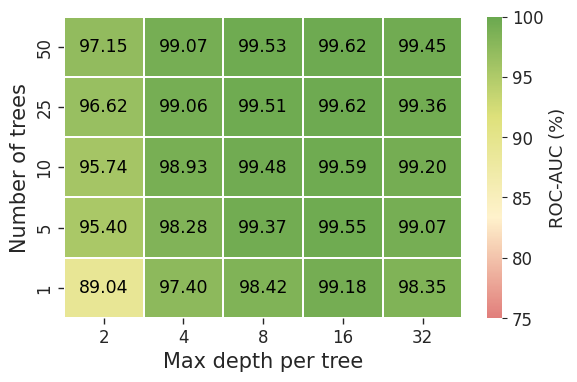

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Load CSV
df = pd.read_csv('exp2_tree_size/rf_grid_search_results.csv')

# Filter dataset
df_ws8 = df[df['dataset'] == 'ws8'].copy()

# Ensure numeric
df_ws8['max_depth'] = pd.to_numeric(df_ws8['max_depth'], errors='coerce')
df_ws8['n_estimators'] = pd.to_numeric(df_ws8['n_estimators'], errors='coerce')

# Convert ROC-AUC to %
df_ws8['roc_auc'] = df_ws8['roc_auc'] * 100.0

# Pivot
pivot = df_ws8.pivot_table(
    index='n_estimators',
    columns='max_depth',
    values='roc_auc',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

# ---- Font sizes (global) ----
plt.rcParams.update({
    "font.size": 12.5,
    "axes.labelsize": 15,
    # "axes.titlesize": 20,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# plt.rcParams.update({
#     "font.size": 14,          # base font size
#     "axes.labelsize": 13,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
#     # "colorbar.labelsize": 10
# })

# ---- Custom hex colormap ----
hex_colors = ["#E17E7B", "#fff2cc", "#dee17b", "#6aa84f"]
cmap = LinearSegmentedColormap.from_list("custom_blue", hex_colors)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=75, vmax=100,
    linewidths=0.003,
    # linecolor="white",
    annot_kws={"color": "black"},
    cbar_kws={"label": "ROC-AUC (%)"}
)

ax.tick_params(
    axis='both',        # x and y
    which='both',       # major + minor ticks
    direction='out',     # ticks point inward (paper style)
    length=4,           # tick length
    width=1,
    bottom=True,
    top=False,           # 🔴 show top tick marks
    left=True,
    right=False          # 🔴 show right tick marks
)

# Labels & title
# ax.set_title("ROC-AUC heatmap (%) — dataset: ws8")
ax.set_xlabel("Max depth per tree")
ax.set_ylabel("Number of trees")
ax.invert_yaxis()

# ---- Colorbar font control ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("ROC-AUC (%)", fontsize=13)

plt.tight_layout()
plt.savefig("exp2_tree_size/roc_auc_heatmap_ws8.pdf", dpi=300)
plt.show()


# Exp 3: SHAP

In [29]:
# compute_shap_artifacts_rf.py
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -----------------------------
# Config
# -----------------------------
WINDOW_SIZE = 8
N_ESTIMATORS = 5
MAX_DEPTH = 8

NORMAL_CSV = f"normal_ws{WINDOW_SIZE}.csv"
ATTACK_CSV = f"attack_ws{WINDOW_SIZE}.csv"

OUT_DIR = "exp3_shap"
os.makedirs(OUT_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    "pkt_size_min", "pkt_size_max", "pkt_size_mean",
    "iat_min", "iat_max", "iat_mean",
    "modbus_req_count", "modbus_resp_count"
]

# -----------------------------
# Helpers
# -----------------------------
def plot_confusion_matrix(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def safe_extract_shap_values(shap_values):
    """
    Make SHAP output consistently 2D: (n_samples, n_features)
    Handles:
      - list output from older SHAP versions
      - 3D arrays from some versions
      - Explanation objects from newer versions
    """
    if isinstance(shap_values, list):
        # binary classification: use class 1
        shap_vals = shap_values[1]
    elif hasattr(shap_values, "values"):
        shap_vals = shap_values.values
    else:
        shap_vals = np.array(shap_values)

    # If 3D, select the class axis
    if shap_vals.ndim == 3:
        if shap_vals.shape[2] == 2:
            shap_vals = shap_vals[:, :, 1]
        elif shap_vals.shape[1] == 2:
            shap_vals = shap_vals[:, 1, :]
        else:
            raise ValueError(f"Unexpected SHAP shape: {shap_vals.shape}")

    if shap_vals.ndim != 2:
        raise ValueError(f"Expected 2D SHAP values, got shape {shap_vals.shape}")

    return shap_vals

# -----------------------------
# Load data
# -----------------------------
df_normal = pd.read_csv(NORMAL_CSV).copy()
df_attack = pd.read_csv(ATTACK_CSV).copy()

df_normal["label"] = 0
df_attack["label"] = 1
df = pd.concat([df_normal, df_attack], ignore_index=True)

# Keep only needed columns, drop missing rows
required_cols = FEATURE_COLUMNS + ["label"]
df = df.dropna(subset=required_cols).reset_index(drop=True)

# Ensure numeric features
for c in FEATURE_COLUMNS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=FEATURE_COLUMNS).reset_index(drop=True)

print("Using features:", FEATURE_COLUMNS)
print("Class counts:\n", df["label"].value_counts())

# -----------------------------
# Train/test split
# -----------------------------
X = df[FEATURE_COLUMNS]
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n(a) Model Evaluation")
print(f"Accuracy on test data: {accuracy:.6f}")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

try:
    y_prob = rf_model.predict_proba(X_test)[:, 1]
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
except Exception as e:
    print("ROC AUC not computed:", e)

cm_path = os.path.join(OUT_DIR, f"confusion_matrix_ws{WINDOW_SIZE}.png")
plot_confusion_matrix(
    y_test, y_pred,
    title=f"Confusion Matrix - ws={WINDOW_SIZE}, trees={N_ESTIMATORS}, depth={MAX_DEPTH}",
    out_path=cm_path
)
print(f"Saved confusion matrix to {cm_path}")

# -----------------------------
# sklearn feature importance
# -----------------------------
importances = rf_model.feature_importances_
feature_importances = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\n(b) sklearn Feature Importances")
print(feature_importances)

feature_importances_csv = os.path.join(OUT_DIR, f"feature_importance_ws{WINDOW_SIZE}.csv")
feature_importances_txt = os.path.join(OUT_DIR, f"feature_list_ws{WINDOW_SIZE}.txt")

feature_importances.to_csv(feature_importances_csv, index=False)
with open(feature_importances_txt, "w") as f:
    for feat in feature_importances["feature"]:
        f.write(feat + "\n")

print(f"Saved feature importance CSV to {feature_importances_csv}")
print(f"Saved feature list TXT to {feature_importances_txt}")

# -----------------------------
# SHAP
# -----------------------------
# Use a sample for speed
sample_size = min(5000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)
shap_vals = safe_extract_shap_values(shap_values)

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n(c) SHAP Importances")
print(shap_importance_df)

shap_importance_csv = os.path.join(OUT_DIR, f"shap_importance_ws{WINDOW_SIZE}.csv")
shap_importance_txt = os.path.join(OUT_DIR, f"shap_feature_list_ws{WINDOW_SIZE}.txt")

shap_importance_df.to_csv(shap_importance_csv, index=False)
with open(shap_importance_txt, "w") as f:
    for feat in shap_importance_df["feature"]:
        f.write(feat + "\n")

print(f"Saved SHAP importance CSV to {shap_importance_csv}")
print(f"Saved SHAP feature list TXT to {shap_importance_txt}")

# SHAP bar plot
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
bar_path = os.path.join(OUT_DIR, f"shap_bar_ws{WINDOW_SIZE}.png")
plt.savefig(bar_path, dpi=200)
plt.close()
print(f"Saved SHAP bar plot to {bar_path}")

# SHAP beeswarm plot
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, show=False)
plt.tight_layout()
beeswarm_path = os.path.join(OUT_DIR, f"shap_beeswarm_ws{WINDOW_SIZE}.png")
plt.savefig(beeswarm_path, dpi=200)
plt.close()
print(f"Saved SHAP beeswarm plot to {beeswarm_path}")

# -----------------------------
# Save model
# -----------------------------
model_path = os.path.join(OUT_DIR, f"random_forest_ws{WINDOW_SIZE}_trees{N_ESTIMATORS}_depth{MAX_DEPTH}.pkl")
joblib.dump(rf_model, model_path)
print(f"\nSaved model to {model_path}")

print("\nDone.")

Using features: ['pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'iat_min', 'iat_max', 'iat_mean', 'modbus_req_count', 'modbus_resp_count']
Class counts:
 label
0    357899
1    151727
Name: count, dtype: int64

(a) Model Evaluation
Accuracy on test data: 0.989394
              precision    recall  f1-score   support

           0     0.9855    0.9996    0.9925     71580
           1     0.9989    0.9654    0.9819     30346

    accuracy                         0.9894    101926
   macro avg     0.9922    0.9825    0.9872    101926
weighted avg     0.9895    0.9894    0.9893    101926

Confusion matrix:
[[71549    31]
 [ 1050 29296]]
ROC AUC: 0.9945765354434035
Saved confusion matrix to exp3_shap/confusion_matrix_ws8.png

(b) sklearn Feature Importances
             feature  importance
0   modbus_req_count    0.314622
1      pkt_size_mean    0.216501
2  modbus_resp_count    0.198108
3            iat_max    0.075392
4       pkt_size_max    0.070439
5           iat_mean    0.063146
6    

In [30]:
# -------------------------
# ---- SHAP Computation ----
# -------------------------
import json
import joblib
import numpy as np
import pandas as pd
import shap
import os

print("\n--- Computing SHAP values (TreeExplainer) ---")

# Use a smaller sample if X_test is large
X_test_shap = X_test.sample(n=min(5000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test_shap)

# For binary classification, take positive class (index 1)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_pos = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_pos = shap_values
    try:
        expected_value = explainer.expected_value
    except Exception:
        expected_value = float(np.mean(rf_model.predict_proba(X_train)[:, 1]))

# If SHAP returns a 3D array in your version, reduce it to 2D
shap_pos = np.array(shap_pos)
if shap_pos.ndim == 3:
    if shap_pos.shape[2] == 2:
        shap_pos = shap_pos[:, :, 1]
    elif shap_pos.shape[1] == 2:
        shap_pos = shap_pos[:, 1, :]
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_pos.shape}")

# Global mean absolute SHAP
mean_abs_shap = np.mean(np.abs(shap_pos), axis=0)
shap_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n(c) Mean absolute SHAP values (feature ranking)")
print(shap_df)

# Save artifacts for later plotting
out_dir = "exp3_shap"
os.makedirs(out_dir, exist_ok=True)

joblib.dump(rf_model, os.path.join(out_dir, "model.pkl"))
pd.to_pickle(X_test_shap, os.path.join(out_dir, "X_test.pkl"))
pd.to_pickle(y_test.loc[X_test_shap.index], os.path.join(out_dir, "y_test.pkl"))
np.save(os.path.join(out_dir, "shap_pos.npy"), shap_pos)
np.save(os.path.join(out_dir, "expected_value.npy"), np.array([expected_value]))

with open(os.path.join(out_dir, "numeric_cols.json"), "w") as f:
    json.dump(FEATURE_COLUMNS, f)

feature_importances.to_csv(os.path.join(out_dir, "feature_importances.csv"), index=False)
shap_df.to_csv(os.path.join(out_dir, "shap_df.csv"), index=False)

# Save a CSV with SHAP values for one example (index 0)
example_idx = 0
sample_shap = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "shap_value": shap_pos[example_idx],
    "feature_value": X_test_shap.iloc[example_idx].values
}).sort_values("shap_value", key=lambda x: x.abs(), ascending=False)

sample_shap.to_csv(
    os.path.join(out_dir, f"sample_shap_example_{example_idx}.csv"),
    index=False
)

print("\nSaved artifacts:")
print("- model.pkl")
print("- X_test.pkl")
print("- y_test.pkl")
print("- shap_pos.npy")
print("- expected_value.npy")
print("- feature_names.json")
print("- feature_importances.csv")
print("- shap_df.csv")
print(f"- sample_shap_example_{example_idx}.csv")


--- Computing SHAP values (TreeExplainer) ---

(c) Mean absolute SHAP values (feature ranking)
             feature  mean_abs_shap
0   modbus_req_count       0.167376
1      pkt_size_mean       0.101338
2  modbus_resp_count       0.099759
3           iat_mean       0.041305
4            iat_min       0.038101
5       pkt_size_max       0.032936
6       pkt_size_min       0.026755
7            iat_max       0.024405

Saved artifacts:
- model.pkl
- X_test.pkl
- y_test.pkl
- shap_pos.npy
- expected_value.npy
- feature_names.json
- feature_importances.csv
- shap_df.csv
- sample_shap_example_0.csv


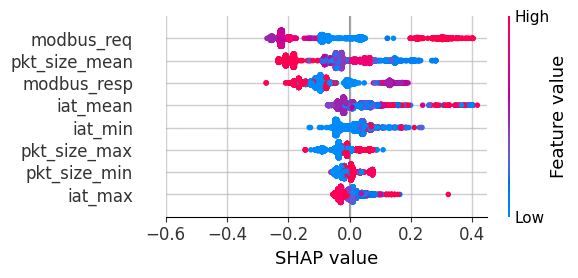

Saved SHAP plot to exp3_shap/shap_8f_8ws.pdf


In [85]:
# plot_shap_artifacts.py
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

ARTIFACT_DIR = "exp3_shap"
OUT_DIR = "exp3_shap"
os.makedirs(OUT_DIR, exist_ok=True)

# Load artifacts
rf_model = joblib.load(os.path.join(ARTIFACT_DIR, "model.pkl"))
X_test = pd.read_pickle(os.path.join(ARTIFACT_DIR, "X_test.pkl"))
y_test = pd.read_pickle(os.path.join(ARTIFACT_DIR, "y_test.pkl"))
shap_pos = np.load(os.path.join(ARTIFACT_DIR, "shap_pos.npy"))
ev = np.load(os.path.join(ARTIFACT_DIR, "expected_value.npy"), allow_pickle=True)
ev = np.asarray(ev).squeeze()
expected_value = ev.item() if ev.shape == () else ev[0]

with open(os.path.join(ARTIFACT_DIR, "numeric_cols.json"), "r") as f:
    numeric_cols = json.load(f)

shap_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "shap_df.csv"))
feature_importances = pd.read_csv(os.path.join(ARTIFACT_DIR, "feature_importances.csv"))

# --- SHAP summary plot (global) ---
shap.summary_plot(
    shap_pos,
    X_test,
    feature_names=numeric_cols,
    show=False
)

plt.gcf().set_size_inches(6, 3)
ax = plt.gca()

# Add grid
ax.grid(True, which='major', axis='both',
        linestyle='-', linewidth=1, alpha=0.6)

# Axis limits & ticks
ax.set_xlim(-0.6, 0.45)
ax.set_xticks([-0.6, -0.4, -0.2, 0.0, 0.2, 0.4])

# Force font sizes
for label in ax.get_yticklabels():
    label.set_fontsize(12)

for label in ax.get_xticklabels():
    label.set_fontsize(12)

ax.set_xlabel("SHAP value", fontsize=13)
ax.xaxis.label.set_size(13)

plt.tight_layout()
fig = plt.gcf()

# Make colorbar thinner
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([
    pos.x0,
    pos.y0,
    pos.width * 2,
    pos.height
])
cbar_ax.set_ylabel("Feature value", fontsize=13)

plt.tight_layout()

# Save first, then show
out_path = os.path.join(OUT_DIR, "shap_8f_8ws.pdf")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved SHAP plot to {out_path}")

# Exp 4: Online

In [32]:
import os
import joblib
import numpy as np
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
MODEL_PATH = "/home/ubuntu/offline_new/attack_trained_models/random_forest_ws8_trees5_depth8.pkl"     # your saved RF model
TEST_CSV = "/home/ubuntu/offline_new/attack_trained_features/attack_ws4.csv"               # or normal_ws32.csv, or any test file
OUT_DIR = "attack_trained_models_json"
OUT_HEADER = "test_data.h"

# -----------------------------
# Features used by your model
# -----------------------------
feature_columns = [
    "pkt_size_min", "pkt_size_max", "pkt_size_mean",
    "iat_min", "iat_max", "iat_mean",
    "modbus_req_count", "modbus_resp_count"
]

# -----------------------------
# Load saved model
# -----------------------------
rf_model = joblib.load(MODEL_PATH)
print(f"Loaded model from: {MODEL_PATH}")

# -----------------------------
# Load test data
# -----------------------------
df_test = pd.read_csv(TEST_CSV).copy()

# If label exists, keep it only for reference; not needed for header generation
if "label" in df_test.columns:
    df_test = df_test.drop(columns=["label"])

# Keep only the needed features
missing = [c for c in feature_columns if c not in df_test.columns]
if missing:
    raise ValueError(f"Missing required feature columns in test data: {missing}")

# Ensure numeric
for c in feature_columns:
    df_test[c] = pd.to_numeric(df_test[c], errors="coerce")

# Drop rows with invalid values
df_test = df_test.dropna(subset=feature_columns).reset_index(drop=True)

X_test = df_test[feature_columns]
X_all = X_test.values

if X_all.ndim != 2:
    raise ValueError(f"X_test must be 2D, got shape {X_all.shape}")

n = X_all.shape[0]
n_features = X_all.shape[1]

print("Using features:", feature_columns)
print(f"Test samples: {n}")

# -----------------------------
# Predict using loaded model
# -----------------------------
y_pred_idx = rf_model.predict(X_all)

# Optional string labels if you have a label encoder in memory
try:
    le
    y_pred_str = le.inverse_transform(y_pred_idx)
except Exception:
    y_pred_str = np.array([str(int(v)) for v in y_pred_idx])

# -----------------------------
# Helper for C float formatting
# -----------------------------
def fmt_f(x):
    return f"{float(x):.8e}f"

# -----------------------------
# Write header
# -----------------------------
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, OUT_HEADER)

with open(out_path, "w") as f:
    f.write("/* Auto-generated test data header */\n")
    f.write("#ifndef TEST_DATA_H\n")
    f.write("#define TEST_DATA_H\n\n")
    f.write("#include <stddef.h>\n\n")

    f.write("/* Number of test samples and feature dimension */\n")
    f.write(f"static const size_t TEST_N = {n}u;\n")
    f.write(f"static const size_t TEST_F = {n_features}u;\n\n")

    f.write("/* Feature array: X_test (row-major) */\n")
    f.write(f"static const float X_test[{n}][{n_features}] = {{\n")
    for i in range(n):
        row_vals = ", ".join(fmt_f(v) for v in X_all[i])
        f.write(f"    {{ {row_vals} }},\n")
    f.write("};\n\n")

    f.write("/* Expected label indexes */\n")
    f.write(f"static const int y_expected[{n}] = {{\n    ")
    f.write(", ".join(str(int(v)) for v in y_pred_idx))
    f.write("\n};\n\n")

    f.write("/* Optional: string labels */\n")
    f.write(f"static const char* y_expected_str[{n}] = {{\n")
    for s in y_pred_str:
        esc = str(s).replace("\\", "\\\\").replace('"', '\\"')
        f.write(f'    "{esc}",\n')
    f.write("};\n\n")

    f.write("#endif /* TEST_DATA_H */\n")

print(f"Header file written to: {out_path} ({n} samples x {n_features} features).")

Loaded model from: /home/ubuntu/offline_new/attack_trained_models/random_forest_ws8_trees5_depth8.pkl
Using features: ['pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 'iat_min', 'iat_max', 'iat_mean', 'modbus_req_count', 'modbus_resp_count']
Test samples: 302928


/home/ubuntu/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Header file written to: attack_trained_models_json/test_data.h (302928 samples x 8 features).


In [36]:
import os
import pickle
import json
from pathlib import Path
import joblib

# -----------------------------
# Config
# -----------------------------
MODEL_DIR = "/home/ubuntu/offline_new/attack_trained_models"
OUTPUT_DIR = "/home/ubuntu/offline_new/attack_trained_models_json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Robust loader (joblib + pickle)
# -----------------------------
def load_model(path):
    try:
        obj = joblib.load(path)
    except Exception:
        with open(path, "rb") as f:
            obj = pickle.load(f)

    # Handle bundle case {"model": rf, ...}
    if isinstance(obj, dict) and "model" in obj:
        return obj["model"]

    return obj

# -----------------------------
# Convert RF to JSON
# -----------------------------
def rf_to_json(rf_model):
    rf_data = {
        "n_estimators": len(rf_model.estimators_),
        "max_depth": rf_model.max_depth,
        "feature_importances": rf_model.feature_importances_.tolist(),
        "estimators": []
    }

    for estimator in rf_model.estimators_:
        tree = estimator.tree_

        estimators_data = {
            "n_nodes": int(tree.node_count),
            "children_left": tree.children_left.tolist(),
            "children_right": tree.children_right.tolist(),
            "feature": tree.feature.tolist(),
            "threshold": tree.threshold.tolist(),
            "class_label": [],
            "leaves": []
        }

        values = tree.value
        classes = estimator.classes_.tolist()

        for i in range(int(tree.node_count)):
            is_leaf = int(tree.children_left[i] == tree.children_right[i])
            estimators_data["leaves"].append(is_leaf)

            if is_leaf:
                class_counts = values[i, 0]
                max_class_index = int(class_counts.argmax())
                estimators_data["class_label"].append(int(classes[max_class_index]))
            else:
                estimators_data["class_label"].append(-10)

        rf_data["estimators"].append(estimators_data)

    return rf_data

# -----------------------------
# Iterate over all .pkl files
# -----------------------------
model_paths = sorted(Path(MODEL_DIR).glob("*.pkl"))

print(f"Found {len(model_paths)} model files")

for model_path in model_paths:
    print(f"\nProcessing: {model_path.name}")

    try:
        rf_model = load_model(model_path)

        rf_json = rf_to_json(rf_model)

        output_path = Path(OUTPUT_DIR) / (model_path.stem + ".json")

        with open(output_path, "w") as f:
            json.dump(rf_json, f, indent=2)

        print(f"Saved JSON to: {output_path}")

    except Exception as e:
        print(f"❌ Failed on {model_path.name}: {e}")

print("\nDone.")

Found 5 model files

Processing: random_forest_ws8_trees10_depth8.pkl
Saved JSON to: /home/ubuntu/offline_new/attack_trained_models_json/random_forest_ws8_trees10_depth8.json

Processing: random_forest_ws8_trees1_depth8.pkl
Saved JSON to: /home/ubuntu/offline_new/attack_trained_models_json/random_forest_ws8_trees1_depth8.json

Processing: random_forest_ws8_trees25_depth8.pkl
Saved JSON to: /home/ubuntu/offline_new/attack_trained_models_json/random_forest_ws8_trees25_depth8.json

Processing: random_forest_ws8_trees50_depth8.pkl
Saved JSON to: /home/ubuntu/offline_new/attack_trained_models_json/random_forest_ws8_trees50_depth8.json

Processing: random_forest_ws8_trees5_depth8.pkl
Saved JSON to: /home/ubuntu/offline_new/attack_trained_models_json/random_forest_ws8_trees5_depth8.json

Done.


File: latencies_att_rf_ws8_depth8_est1.csv | col='rf_ns' | n=302928 | min=0.04 | max=346.06 | median=0.06 | mean=0.11 | std=2.34
File: latencies_att_rf_ws8_depth8_est5.csv | col='rf_ns' | n=302928 | min=0.11 | max=255.33 | median=0.14 | mean=0.20 | std=2.26
File: latencies_att_rf_ws8_depth8_est10.csv | col='rf_ns' | n=302928 | min=0.20 | max=353.58 | median=0.27 | mean=0.33 | std=2.54
File: latencies_att_rf_ws8_depth8_est25.csv | col='rf_ns' | n=302928 | min=0.53 | max=278.06 | median=0.67 | mean=0.79 | std=2.83
File: latencies_att_rf_ws8_depth8_est50.csv | col='rf_ns' | n=302928 | min=1.05 | max=289.56 | median=1.34 | mean=1.61 | std=3.37


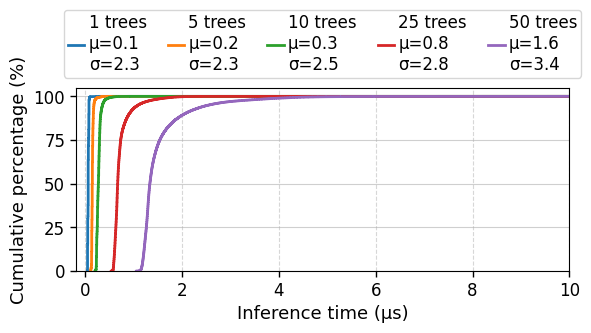

In [86]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "exp4_online"
PATTERN = "latencies_att_rf_ws8_depth8_est*.csv"
OUT_PLOT = os.path.join(DATA_DIR, "latency_cdfs_ws8_depth32.pdf")

FIGSIZE = (6.3, 4.5)
LINEWIDTH = 2
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # 5 distinct colors
MARKERS = [None]*5

# Helper: choose a latency column
def find_latency_column(df):
    candidates = [c for c in df.columns if c.lower() in (
        'latency','lat_ms','latency_ms','response_time','response_ms','lat','rtt','rt_ms')]
    if candidates:
        return candidates[0]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for c in numeric_cols:
        if df[c].dropna().size > 0:
            vals = pd.to_numeric(df[c], errors='coerce').dropna().values
            if vals.size > 10:
                diffs = np.diff(vals.astype(float))
                if np.all(diffs == 1) or np.all(diffs == 0):
                    continue
            return c
    raise RuntimeError("No suitable numeric column found for latency.")

def extract_est(fp):
    m = re.search(r"est(\d+)", os.path.basename(fp))
    return int(m.group(1)) if m else float("inf")

# Find files and sort by numeric est value (1,5,10,25,50)
files = sorted(
    glob.glob(os.path.join(DATA_DIR, PATTERN)),
    key=extract_est
)

if not files:
    raise RuntimeError(f"No files found matching {PATTERN} in {DATA_DIR}")

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
fig, ax = plt.subplots(figsize=FIGSIZE)

handles = []
labels = []

for i, fp in enumerate(files):
    df = pd.read_csv(fp)
    lat_col = find_latency_column(df)
    vals = pd.to_numeric(df[lat_col], errors='coerce').dropna().astype(float).values

    # --- Convert from nanoseconds to microseconds ---
    # NOTE: original data are ns -> divide by 1000 to get μs
    vals = vals / 1000.0

    # Debug summary
    if len(vals):
        mean_lat = np.mean(vals)
        std_lat = np.std(vals, ddof=1)
        print(
            f"File: {os.path.basename(fp)} | col='{lat_col}' | "
            f"n={len(vals)} | "
            f"min={np.min(vals):.2f} | "
            f"max={np.max(vals):.2f} | "
            f"median={np.median(vals):.2f} | "
            f"mean={mean_lat:.2f} | "
            f"std={std_lat:.2f}"
        )
    else:
        print(f"File: {os.path.basename(fp)} | col='{lat_col}' | n=0 | no valid values")
        continue

    # sort and CDF (percentage)
    vals_sorted = np.sort(vals)
    n = vals_sorted.size
    y = np.arange(1, n + 1) / n * 100.0

    # extract numeric trees count
    trees = extract_est(fp)

    color = COLORS[i % len(COLORS)]

    # Use plot with drawstyle='steps-post' to get a Line2D handle
    line, = ax.plot(vals_sorted, y, drawstyle='steps-post',
                    linewidth=LINEWIDTH, color=color)

    # Save handle and a two-line legend label: first line = trees, second line = stats
    label = (
        f"{trees} trees\n"
        f"μ={mean_lat:.1f}\n"
        f"σ={std_lat:.1f}"
    )
    handles.append(line)
    labels.append(label)

    # optional: markers downsample
    if MARKERS[i]:
        idx = np.linspace(0, n-1, min(80, n)).astype(int)
        ax.plot(vals_sorted[idx], y[idx], linestyle='None',
                marker=MARKERS[i], color=color, markersize=4)

# Cosmetics
ax.set_xlabel("Inference time (μs)")
ax.set_ylabel("Cumulative percentage (%)")
# Y grid (solid)
ax.grid(True, axis='y', linestyle='-', linewidth=0.8, alpha=0.6)
# X grid (dashed)
ax.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 105)
ax.set_xlim(-0.2, 10)
# ax.set_xscale("symlog")

ax.tick_params(
    axis='both',        # x and y
    which='both',       # major + minor ticks
    direction='out',     # ticks point inward (paper style)
    length=4,           # tick length
    width=1,
    bottom=True,
    top=False,           # 🔴 show top tick marks
    left=True,
    right=False          # 🔴 show right tick marks
)

# Legend above plot, multi-column, with title explaining the numbers are tree counts
legend = ax.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.47),  # slightly higher for 3-line entries
    ncol=5,                     
    frameon=True,
    # title="Number of trees"
    columnspacing=1.25,     # horizontal spacing between columns
    handletextpad=0.25,     # space between line symbol and text
    labelspacing=0.1,      # vertical spacing between lines
    borderpad=0.25,          # padding inside legend box
    handlelength=1 
)

# Make legend title clarify units (optional)
legend.get_title().set_fontsize(10)
# Left-align multiline legend texts
for text in legend.get_texts():
    text.set_multialignment('left')

fig.subplots_adjust(left=0.001, right=1.5)

# Tight layout and save
plt.tight_layout()
os.makedirs(os.path.dirname(OUT_PLOT) or ".", exist_ok=True)
plt.savefig(OUT_PLOT, dpi=300, bbox_inches='tight')
plt.show()
